# Name: Mo Mottaleb (632001349)
# Date: 03/17/2026
# CSCE 676
# Project Checkpoint 2


# 1. Project Scope

In [ ]:
# Imports libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Dataset Recap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1.1 Load dataset

path = '/content/drive/MyDrive/CSCE676/Project/creditcard.csv'
df = pd.read_csv(path)

print("Shape:", df.shape)
print(df.head())

# 1.2 Quick data info and missing value check
print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

Dataset: Kaggle Credit Card Fraud Detection  

- 284,807 transactions, 492 frauds (≈0.172% positive class)  
  - Features:  
      - Time: seconds elapsed between each transaction and the first transaction  
      - Amount: transaction amount  
      - Class: 1 = fraud, 0 = non-fraud  
      - V1-V28: PCA-anonymized features from original transaction attributes
  - No missing data -> Requires no imupation

 - Dataset exhibits extreme amounts for fraud/non-fraud -> Applications could be used for highly imbalanced binary classification and pattern discovery in fraud behavior.

## 1.2 EDA Recap

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class ratio:
 Class
0    0.998273
1    0.001727
Name: count, dtype: float64


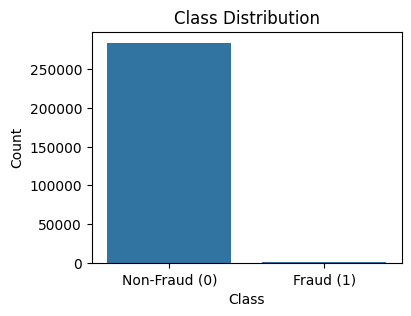

In [ ]:
# Class distribution

class_counts = df['Class'].value_counts()
class_ratio = class_counts / len(df)

print("Class counts:\n", class_counts)
print("\nClass ratio:\n", class_ratio)

plt.figure(figsize=(4,3))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0,1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

# extreme imbalance (fraud ~0.17%).

**Class imbalance**
- Fraud rate ≈ 0.172% (492/284,807).  

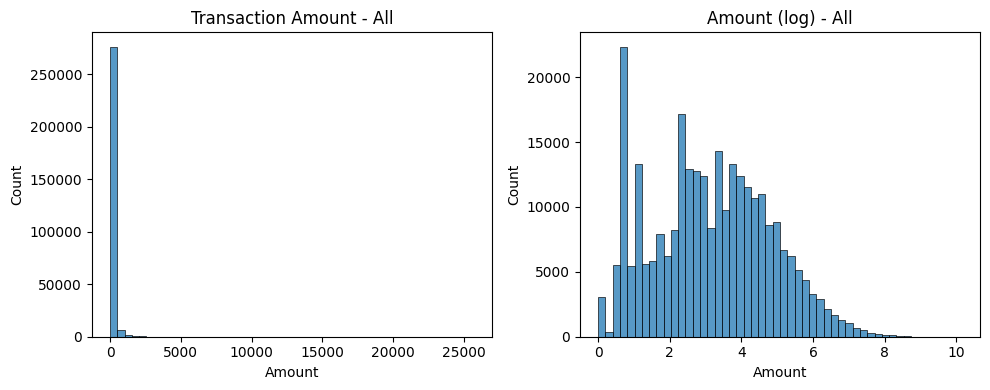

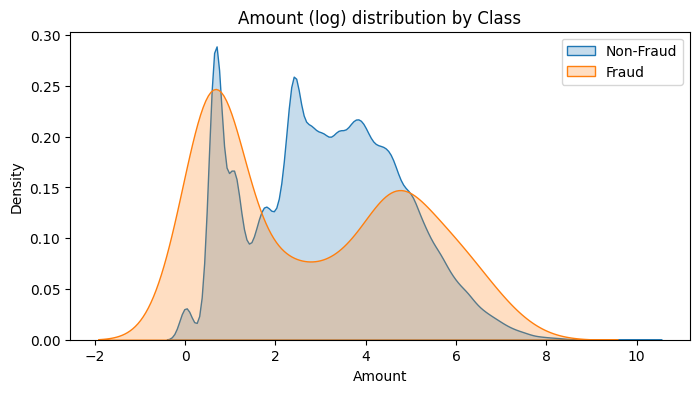

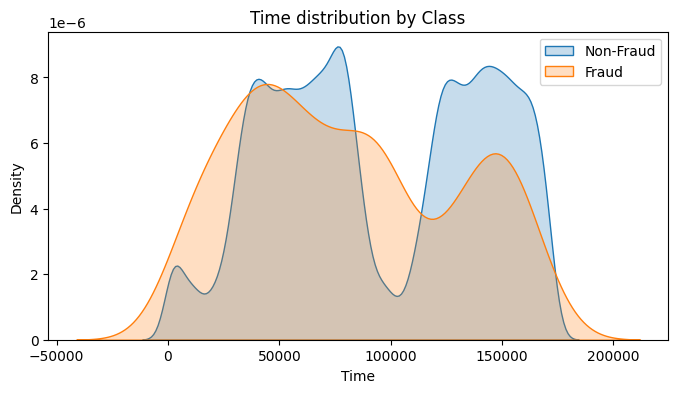

In [ ]:
# Basic distributions of Amount and Time by class

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Amount'], bins=50, kde=False)
plt.title('Transaction Amount - All')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['Amount']), bins=50, kde=False)
plt.title('Amount (log) - All')
plt.tight_layout()
plt.show()

# Compare Amount distribution by class (log scale for readability)
plt.figure(figsize=(8,4))
sns.kdeplot(np.log1p(df.loc[df['Class']==0, 'Amount']), label='Non-Fraud', fill=True)
sns.kdeplot(np.log1p(df.loc[df['Class']==1, 'Amount']), label='Fraud', fill=True)
plt.title('Amount (log) distribution by Class')
plt.legend()
plt.show()

# Time distribution by class
plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Class']==0, 'Time'], label='Non-Fraud', fill=True)
sns.kdeplot(df.loc[df['Class']==1, 'Time'], label='Fraud', fill=True)
plt.title('Time distribution by Class')
plt.legend()
plt.show()

**Time**   
- Fraud and non-fraud occur across the full time span as seen by temporal clustering (e.g., bursts of fraud in certain time windows).  

**Amount**   
- Strong right-skew: many small transactions, few large ones.  
- Fraud may be more probable in certain amount ranges (e.g., mid-range rather than extremely large or tiny).  
     


V4 summary:
count    2.848070e+05
mean     2.074095e-15
std      1.415869e+00
min     -5.683171e+00
25%     -8.486401e-01
50%     -1.984653e-02
75%      7.433413e-01
max      1.687534e+01
Name: V4, dtype: float64


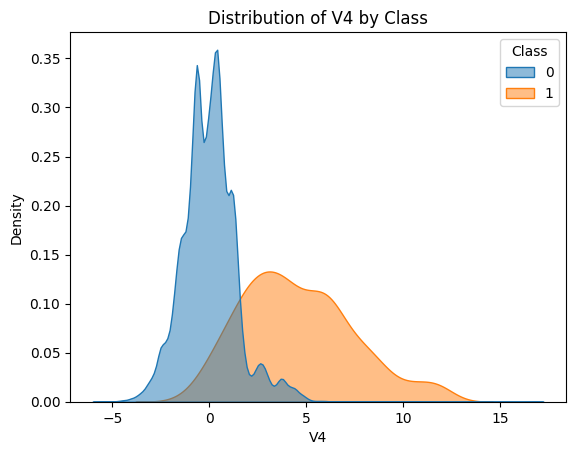


V8 summary:
count    2.848070e+05
mean     1.213481e-16
std      1.194353e+00
min     -7.321672e+01
25%     -2.086297e-01
50%      2.235804e-02
75%      3.273459e-01
max      2.000721e+01
Name: V8, dtype: float64


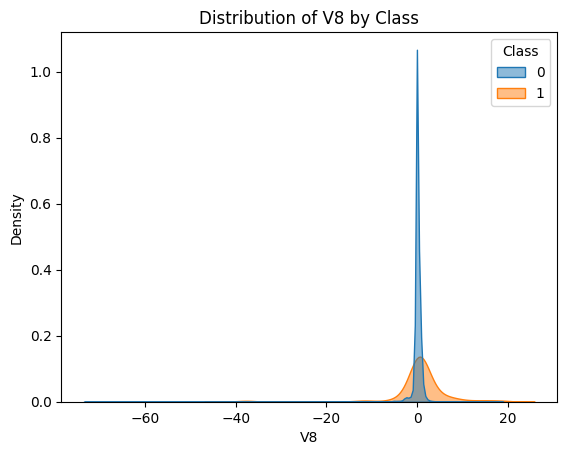


V12 summary:
count    2.848070e+05
mean    -1.247012e-15
std      9.992014e-01
min     -1.868371e+01
25%     -4.055715e-01
50%      1.400326e-01
75%      6.182380e-01
max      7.848392e+00
Name: V12, dtype: float64


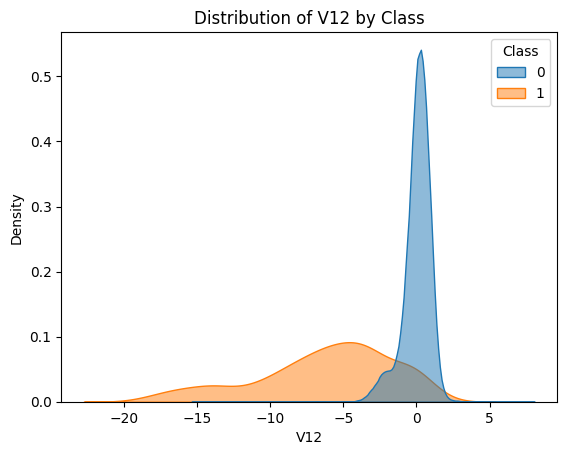


V16 summary:
count    2.848070e+05
mean     1.437716e-15
std      8.762529e-01
min     -1.412985e+01
25%     -4.680368e-01
50%      6.641332e-02
75%      5.232963e-01
max      1.731511e+01
Name: V16, dtype: float64


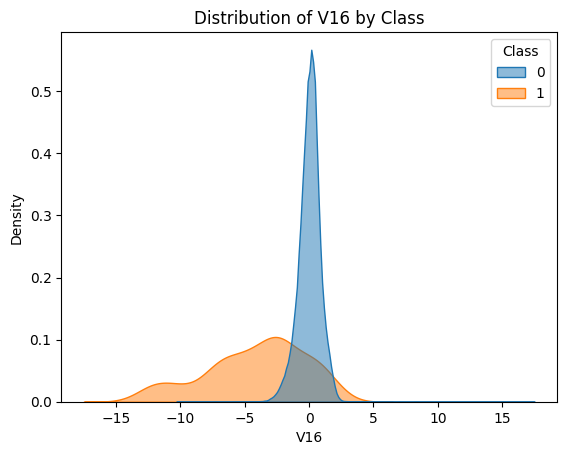


V20 summary:
count    2.848070e+05
mean     6.406204e-16
std      7.709250e-01
min     -5.449772e+01
25%     -2.117214e-01
50%     -6.248109e-02
75%      1.330408e-01
max      3.942090e+01
Name: V20, dtype: float64


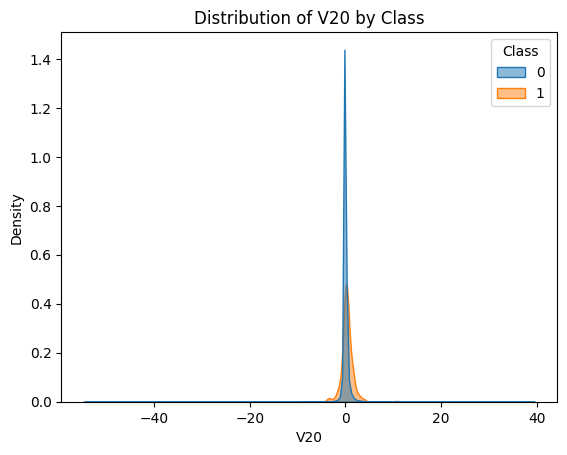


V24 summary:
count    2.848070e+05
mean     4.473266e-15
std      6.056471e-01
min     -2.836627e+00
25%     -3.545861e-01
50%      4.097606e-02
75%      4.395266e-01
max      4.584549e+00
Name: V24, dtype: float64


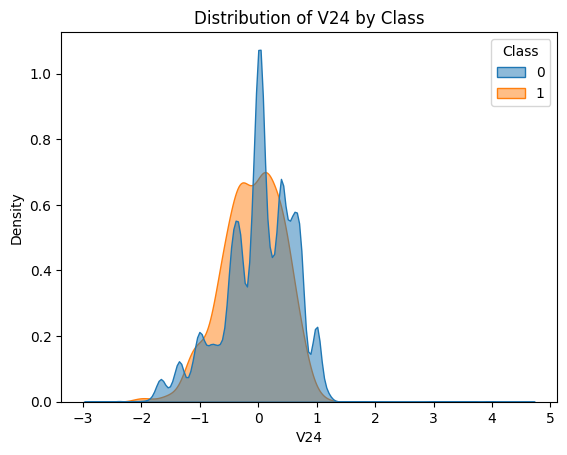

In [ ]:
features_to_inspect = ['V4', 'V8', 'V12', 'V16', 'V20', 'V24']

for col in features_to_inspect:
    print(f"\n{col} summary:")
    print(df[col].describe())

    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Class', common_norm=False, fill=True, alpha=0.5)
    plt.title(f"Distribution of {col} by Class")
    plt.show()

Top correlations with Time:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
Name: Class, dtype: float64

Lowest correlations with Time:
V13    -0.004570
V24    -0.007221
Time   -0.012323
V6     -0.043643
V5     -0.094974
V9     -0.097733
V1     -0.101347
V18    -0.111485
V7     -0.187257
V3     -0.192961
V16    -0.196539
V10    -0.216883
V12    -0.260593
V14    -0.302544
V17    -0.326481
Name: Class, dtype: float64


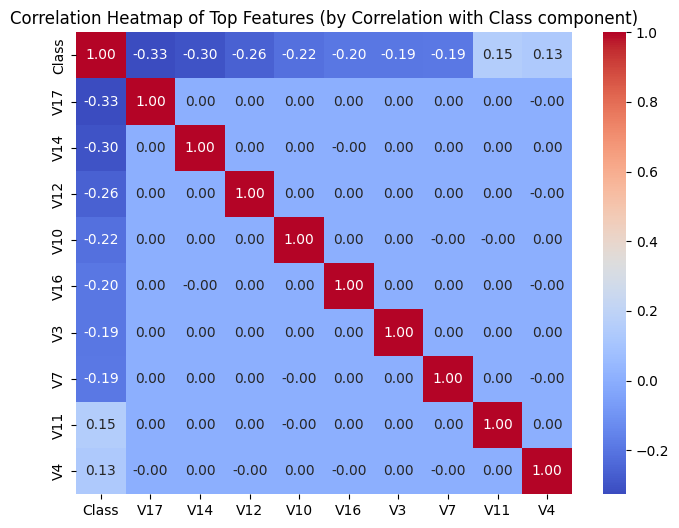

In [ ]:
# Group into 1-hour bins
bin_size = 3600  # seconds
df['Time_bin'] = (df['Time'] // bin_size).astype(int)

txn_per_bin = df.groupby('Time_bin')['Class'].count()
fraud_per_bin = df.groupby('Time_bin')['Class'].sum()

corr_matrix = df.drop(columns=['Time_bin']).corr()
# The correlation is done in repect to (i.r.t) to Class component/variable
corr_with_class = corr_matrix['Class'].sort_values(ascending=False)

print("Top correlations with Time:")
print(corr_with_class.head(15))
print("\nLowest correlations with Time:")
print(corr_with_class.tail(15))

top_corr_features = corr_with_class.abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(8, 6))
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Top Features (by Correlation with Class component)")
plt.show()

**Feature distributions & correlations**
- V-features show different distributions for fraud vs non-fraud (e.g., some V’s have distinct means and spreads), as shown above.
- Correlation heatmap suggests some features are more predictive, but they’re anonymized.

# 2. Research Quesitons (RQs) Formulation

All the RQs posted below provides the following data preprocessing steps (to ensure the EDA and later downstream pipepline processing can be accurately conducted):

1. Data Loading from Source (Kaggle CSV file of Credit Card Fraud Detection).   
    - Document file path and integrity checks (row count, missing values).
    
2. Handle missing values, if applicable, using imputation and/or dropping  
Feature scaling:
    - Standardize features for distance-based/clustering/anomaly methods (e.g., StandardScaler on Time, Amount, and V1–V28).  
    
3. Train/validation/test split:
    - Stratified split by Class to preserve class ratio.  
      - Example: 60% train / 20% validation / 20% test or 70/15/15 or other combinations for train/validation/test.     


## 2.1 RQ1 (Course technique): Threshold & cost-sensitive evaluation

***Proposed Question: How do different supervised classification algorithms (e.g., logistic regression, decision trees, random forests) trade off precision, recall, and cost-sensitive performance when detecting fraudulent transactions under varying decision thresholds?***

The outline below provides methodology plan to perform RQ1 testing/analysis. The outline is subject to change as more in-depth is conducted.

------

**Outline/Planning for RQ1**

1. *Data mining task type*
    - Supervised classification on highly imbalanced data.   

2. *Relevant algorithm(s) (Data Mining Class)*
    - Logistic Regression  
    - Decision Tree  
    - Random Forest     

3. *Evaluation criteria*  
    - Standard metrics:  
      - Receiver Operating Curve - Area Under Curve (ROC-AUC)
      - Precision Recall - Area Under Curve (PR-AUC)  
      - Recall (sensitivity) for fraud class  
      - Precision and F1 for fraud class
         
    - Cost-sensitive metrics:
      - Weighted misclassification cost:  
        - Define cost matrix, e.g.,  
          - Cost(MF) = C_MF (missed fraud: high cost)  
          - Cost(FA) = C_FA (false alarm: lower cost)            
      - Evaluate expected cost per transaction under each decision threshold.         
         
    - Decision threshold analysis:
      - Scan thresholds (e.g. 0.01-0.5), with default = 0.5, and analyze trade-offs using:
        - Precision-Recall curves  
        - Cost vs threshold curves.
                 

4. *Intersting/Non-Trivial Features*
    - With extreme imbalance, accuracy is meaningless. The business problem is inherently cost-sensitive (missing fraud is much worse than false alarms), so exploring thresholds and costs is meaningful.
    - Non-trivial because:
      - Need to deal with imbalance (via resampling and/or class weights).  
      - Need to interpret models not just by ROC-AUC, but in terms of realistic cost trade-offs.

## 2.2 RQ2 (Course technique): Clustering-based structure in fraud vs non-fraud


***Proposed Question: Do fraud and non-fraud transactions exhibit distinct cluster structures in the PCA-based feature space, and can clustering help identify subtypes of fraudulent transactions?***


The outline below provides methodology plan to perform RQ2 testing/analysis. The outline is subject to change as more in-depth is conducted.

------

**Outline/Planning of RQ2:**

1. *Data mining task type*   
    - Unsupervised learning (clustering), then post-hoc analysis against labels.
          

2. *Relevant algorithm(s) (Data Mining Class)*   
    - k-means clustering (on selected features)       

3. *Evaluation criteria*   
    - Internal clustering metrics:
      - Silhouette score  
      - Davies-Bouldin index

    - External / interpretability:
      - Fraud prevalence per cluster  
      - Whether certain clusters are enriched in fraud compared to global base rate.  
      - Difference in feature distributions across clusters (e.g., boxplots of Amount, selected V's).

4. *Interesting/Non-Trivial Features*  
    - Finds structure beyond a simple “fraud vs non-fraud” dichotomy.  
    - Can reveal subtypes of fraud (e.g., low-amount frequent fraud vs high-amount rare fraud) that might need different handling.  
    - Non-trivial because:
      - Clusters may be dominated by non-fraud; masked patterns require careful sampling or weighting.  
      - Evaluating clusters against extremely imbalanced labels is subtle.
       
     

## 2.3 RQ3 (External Course Technique): Anomaly detection / imbalance-aware external method     

***Proposed Question: How do kernel-based (One-Class SVM) and neural (autoencoder) anomaly detection methods compare in detecting fraudulent transactions, and do they flag complementary sets of frauds relative to supervised classifiers?***

The outline below provides methodology plan to perform RQ3 testing/analysis. The outline is subject to change as more in-depth is conducted.

------

**Outline/Planning for RQ3**

1. *Data mining task type*   
    - Primary task: Unsupervised / semi-supervised anomaly detection  
    - Secondary task: Comparative evaluation vs supervised classification
  
2. *Relevant algorithm(s) (external)*   
    - External algorithms (anomaly detection):
        - One-Class SVM (kernel-based anomaly detector -> RBF kernel)  
        - Autoencoder (neural network trained to reconstruct “normal” transactions; reconstruction error as anomaly score)
    - Baseline / reference (supervised classifiers):
        - A strong supervised model from RQ1 (e.g., Random Forest, XGBoost, or Logistic Regression with class weights)  
        - May use Isolation Forest as an additional anomaly baseline
           
     
3. *Evaluation criteria*  
    - Global ranking quality (threshold-free):
      - ROC-AUC of anomaly scores vs fraud labels  
      - PR-AUC (Average Precision) to better reflect rare positive class
    - Top-k detection quality (operational focus):
      - For multiple top fractions (e.g., top 0.1%, 0.5%, 1%, most anomalous):
          - Precision@k (fraction of flagged transactions that are actually fraud)  
          - Recall@k (fraction of all frauds that are flagged in the top k)
    - Complementarity vs supervised classifier:
        - Overlap analysis:
            - Set overlap between top-k fraud candidates detected by:
                - One-Class SVM  
                - Autoencoder  
                - Supervised classifier (e.g., Random Forest probabilities)  
            - Number of frauds:
                - Detected only by One-Class SVM  
                - Detected only by Autoencoder  
                - Detected only by the supervised classifier  
                - Detected by multiple methods  

4. *Interesting/non-trivial Features*   
    - Many real-world fraud problems have limited or delayed labels -> anomaly detection is valuable.  
    - Non-trivial because:
      - Isolation Forest requires tuning contamination parameter and tree-related hyperparameters.  
      - Needs careful evaluation with imbalanced metrics (PR-AUC, top-k precision).          
     

# 3. Motivation and Feasibility of RQs

## 3.1 RQ1: Motivation, Non-Triviality, Feasibility, Risks


**Motivation**   
- EDA shows extreme class imbalance.  
- Raw accuracy is near 100% if predicting all non-fraud; not useful.  
- Real-world cost asymmetry: missing a fraud costs significantly more than a false alarm.

**Non-triviality**   
- Requires using appropriate metrics that account for imbalance (PR-AUC, cost).  
- Requires varying decision thresholds rather than relying on default 0.5.  
- Requires possibly incorporating class weights or resampling to get sensible models.
          
**Feasibility**   
- Dataset size (~285k rows) is manageable with standard models.  
- Logistic regression, decision trees, and random forests are readily available in scikit-learn and quick to train.
      

**Risks & mitigation**   
- Risk 1: Overfitting if too many hyperparameters are tuned without proper validation.  
    - Mitigation 1: Use train/validation/test split or cross-validation.
      
- Risk 2: Threshold choice may be arbitrary.  
  - Mitigation 2: Use cost curves and PR curves to rationalize threshold selection.

## 3.2 RQ2: Motivation, Non-Triviality, Feasibility, Risks

**Motivation**   
- EDA suggests differences in V-feature distributions for fraud vs non-fraud.  
- Clustering might reveal “types” of transactions; some clusters may have elevated fraud risk.
      

**Non-triviality**   
- Fraud is extremely rare; clustering the entire dataset naively will primarily separate non-fraud structure.  
- Must think carefully: maybe oversample fraud or select a balanced subsample to reveal patterns.
      

**Feasibility**
- k-means scales well to this dataset, especially if:
    - Standardize features.  
    - Possibly use a subset (e.g., 50k–100k transactions) for initial cluster exploration.
        
- Visualization with 2D/3D PCA/t-SNE is feasible.
      

**Risks & Mitigation**   
- Risk 1: Clusters may not align strongly with fraud/non-fraud; patterns could be weak.  
  - Mitigation 1:
    - Evaluate more than one k
    - Try different feature subsets
    - Interpret clusters via feature distributions, not only via label enrichment.
      
- Risk 2: t-SNE/UMAP can be unstable and time-consuming.  
  - Mititagation 2:
    - Use PCA for main analysis;
    - t-SNE only on a subsample for qualitative visualization.
         
     

## 3.3 RQ3: Motivation, Non-Triviality, Feasibility, Risks

**Motivation**   
- Fraud is rare and may evolve; purely supervised methods can struggle with unseen patterns or limited labels.    
- Kernel-based and neural anomaly detectors capture different types of structure in “normal” data:
  - One-Class SVM learns a boundary in feature space (kernel geometry).
  - Autoencoders learn a low-dimensional manifold and flag points with high reconstruction error.
- Comparing them to a strong supervised classifier reveals whether they add value (e.g., catching frauds that supervised models miss).


**Non-triviality**   
- Careful selection and tuning of One-Class SVM (nu, gamma) and autoencoder architecture.  
- Designing fair evaluation protocols (same train/val/test splits, same top-k budgets).  
- Interpreting differences in detection sets, not just aggregate metrics.


**Feasibility**   
- Data is numeric and already PCA-transformed, well-suited for SVM and autoencoders.  
- One-Class SVM and autoencoders are available in common libraries (sklearn, keras/tensorflow or pytorch).  
- Can train autoencoder and One-Class SVM on the following:
  - Non-fraud-only subset (to model “normal”)
  - A large subset of mostly non-fraud data.   
      

**Risks & Mitigation**   
- Risk 1: One-Class SVM scalability - May be slow on the full dataset (Run Time Scalability to support fit and predition time)
  - Mitigation 1:
    - Subsampling
    - Feature Selection
    - Reduced Training Set (e.g., 50k-100k non-fraud points).

- Risk 2: Autoencoder tuning complexity - Architecture and regularization significantly affect performance (Parameter Sensitivity)
  - Mitigation 2:  
    - Mitigate with simple, shallow architectures and early stopping on validation reconstruction loss.
     
- Risk 3: Underperforming supervised methods - This is itself informative result can show where anomaly detection is helpful or limited.
  - Mitigation 3:
    - Focus on complementarity (unique frauds caught) as well as raw metrics.
     

# 4. Research Questions, Methods, and Evaluation Summary Table

| RQ  | Task Type                               | Main Algorithms                                      | Course / External | Evaluation Metrics                                                                                          |
|-----|-----------------------------------------|------------------------------------------------------|-------------------|------------------------------------------------------------------------------------------------------------|
| RQ1 | Supervised fraud classification         | Logistic Regression, Decision Tree, Random Forest    | Course            | ROC-AUC, PR-AUC, Precision, Recall, F1 (fraud), cost-based metrics, threshold analysis                     |
| RQ2 | Unsupervised clustering + label analysis| k-means (optional: Agglomerative)                    | Course            | Silhouette score, Davies–Bouldin, fraud rate per cluster, feature distributions                            |
| RQ3 | Advanced Anomaly Detection             | One Class SVM, Autoencoder           | External          | ROC-AUC, PR-AUC, Precision@k, Recall@k, overlap with supervised model predictions                          |

# 5. Github Repo Link

https://github.com/MuhiMoMottaleb/CSCE676_Project/blob/main/ProjectCheckpoint2/ProjectCheckpoint2.ipynb

# 6. Resources/Assumptions:

On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k: Website about how to use Precision and Recall @ k
- https://www.geeksforgeeks.org/machine-learning/understanding-one-class-support-vector-machines/: Website about overview for One Class SVMs
- https://medium.com/@weidagang/demystifying-anomaly-detection-with-autoencoder-neural-networks-1e235840d879: Article about application of auto encoders for neural networks
- https://www.emergentmind.com/topics/one-class-support-vector-machines-svm: Articel about overview, summary, and strength/weaknesses for One Class SVMs
- https://medium.com/@haj122/when-and-when-not-to-use-svms-e9edea04d6ba: Applications of when (and when not) to use One Class SVMs
- https://pyimagesearch.com/2023/07/10/introduction-to-autoencoders/: Autoencoder overview
- https://www.geeksforgeeks.org/machine-learning/auto-encoders/: Webpage of usage of Autoencoders
- https://medium.com/@douglaspsteen/precision-recall-curves-d32e5b290248: Web Article about explaniation of Precision Recall Curve
- https://www.blog.trainindata.com/auc-roc-analysis/: Article about definition and explanation of ROC-AUC
- https://coralogix.com/ai-blog/ultimate-guide-to-pr-auc-calculations-uses-and-limitations/: Article about definition and explanation of PR-AUC
- https://stats.stackexchange.com/questions/99162/what-is-one-class-svm-and-how-does-it-work: Explanation of One Class SVMs and specific topics, such as Kernel Space
- https://medium.com/data-science/too-many-features-lets-look-at-principal-component-analysis-62504b791ae9: Provides explanation of why PCA is good for machine learning algorithms (e.g. Autoencoders and SVMs)
- https://codefinity.com/courses/v2/124a46b4-f2ae-4cfc-a59c-a24453208422/dd496ea2-4d2c-4604-b7e1-b87d179c96cd/f5f383b9-19c9-41ec-b6b2-ecb32095bd41: One Class SVM, also explains nu and gamma usage for One Class SVM algorithm
- https://www.geeksforgeeks.org/python/rbf-svm-parameters-in-scikit-learn/: Radial Basis Function (RBF) Kernels parameter explanations
- https://www.geeksforgeeks.org/machine-learning/clustering-metrics/: Article about Clustering Metrics

3. AI Tools:
- Used ChatGPT to build Table for Section 4 to summarize result/information

4. Assumptions:
- None

5. Citations:
- Y. Chen, J. Qian and V. Saligrama, "A new one-class SVM for anomaly detection," 2013 IEEE International Conference on Acoustics, Speech and Signal Processing, Vancouver, BC, Canada, 2013, pp. 3567-3571, doi: 10.1109/ICASSP.2013.6638322.
